In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import j0, y0, jn_zeros
from scipy.optimize import brentq

from tqdm import tqdm

### Diffusion Equation in Polar Coordinates

$$
\frac{\partial C(r,t)}{\partial t} = D \left( \frac{\partial^2 C(r,t)}{\partial r^2} + \frac{1}{r} \frac{\partial C(r,t)}{\partial r} \right)
$$

Where:
- C(r,t) is the concentration at radius \( r \) and time \( t \).
- D is the diffusion coefficient.

### Boundary Conditions

1. **Inner Radius :**
   \[
   C(r_1, t) = c_0
   \]

2. **Outer Radius :**
   \[
   C(r_2, t) = c_2
   \]

### Initial Condition

The initial concentration distribution \( C(r, 0) \) is:

$$
C(r, 0) = c_0
$$
$$
r_1 < r < r_2
$$


### Exact solution
$$
C(r,t) = c_1 \frac{\ln\left(\frac{r_2}{r}\right)}{\ln\left(\frac{r_2}{r_1}\right)} + \pi \sum_{n=1}^{\infty} \frac{c_1 J_0(\beta_n r_2) J_0(\beta_n r_1) U_0(\beta_n r)}{J_0^2(\beta_n r_1) - J_0^2(\beta_n r_2)} e^{-\beta^2_n D t}
$$

In [ ]:
def U0(beta, r, r2):
  return j0(beta*r)*y0(beta*r2) - j0(beta*r2)*y0(beta*r)

In [ ]:
def second_term(r, t, r1, r2, c1, D, beta_n) -> float:
  series_value = 0
  for beta in beta_n:
    numerator = c1*j0(beta*r2)*j0(beta*r1)*U0(beta, r, r2)*np.exp(-beta*beta*D*t)
    denominator = j0(beta*r1)**2-j0(beta*r2)**2
    series_value += numerator/denominator
  return np.pi*series_value

In [ ]:
def second_term_vec(r, t, r1, r2, c1, D, beta_n) -> float:
  j0_r2 = j0(beta_n*r2)
  j0_r1 = j0(beta_n*r1)
  U0_vals = U0(beta_n, r, r2)

  numerator = c1*j0_r2*j0_r1*U0_vals*np.exp(-beta_n**2*D*t)
  denominator = j0_r1**2-j0_r2**2
  series_value = np.sum(numerator/denominator)

  return np.pi*series_value

In [ ]:
def first_term(r, r1, r2, c1):
    numerator = np.log(r2 / r)
    denominator = np.log(r2 / r1)
    result = c1 * numerator / denominator
    return result

In [ ]:
def C(r, r1, r2, D, t, c1, beta_n):
  first_value = first_term(r, r1, r2, c1)
  second_value = second_term_vec(r, t, r1, r2, c1, D, beta_n)

  return first_value + second_value

In [ ]:
# input parameters

# TODO: convert to cm

# mm
r1 = 598
r2 = 610

# TODO: check
# relative size
# r1 = 1
# r2 = 13

#  598,000 µm
# r1 = 598*1e3
# r2 = 610*1e3
r = (r1+r2)/2

# ppm
c1 = 4
c2 = 0
c0 = 0


t_start = 1
t_finish = 25*1e3
t_step = 1

# µm²/s
# D = 3.2

# mm^2/s
D = 3.2*1e-3

# m^2/s
# D = 3.2*1e-9

# D = 2.4e-11
# D = 2.4 * 10**-11

In [ ]:
r1, r, r2

(598, 604.0, 610)

In [ ]:
def find_root(beta_interval, r1, r2):
    a, b = beta_interval
    U0_partial = lambda beta: U0(r=r1, r2=r2, beta=beta)
    root = brentq(U0_partial, a, b)  # Using Brent's method from scipy
    return root

In [ ]:
def find_beta_intervals(beta_start=0.01, beta_finish=100, step=0.0001):

# TODO: check correctness

  def find_sign_changes(values):
    sign_changes = []
    for i in range(1, len(values)):
        if (values[i] >= 0 and values[i - 1] < 0) or (values[i] < 0 and values[i - 1] >= 0):
            sign_changes.append((i - 1, i))
    return sign_changes

  # beta_n = np.linspace(beta_start, beta_finish, steps)
  beta_n = np.arange(beta_start, beta_finish, step)
  values = U0(r=r1, r2=r2, beta=beta_n)
  indexes = find_sign_changes(values)

  return beta_n[indexes]

In [ ]:
def find_roots(beta_start, beta_finish, step):
  beta_intervals = find_beta_intervals(beta_start, beta_finish, step)
  roots = [find_root(beta_interval, r1, r2) for beta_interval in beta_intervals]
  return np.array(roots)

In [ ]:
# beta_n = find_roots(beta_start=0.001, beta_finish=100, step=0.001)
beta_n = find_roots(beta_start=0.001, beta_finish=50, step=0.001)

In [ ]:
# beta_n = find_beta_n(r1, r2, n_roots=100)
print(len(beta_n))

190


In [ ]:
beta_n[:10]

array([0.26179808, 0.52359812, 0.78539773, 1.04719722, 1.30899668,
       1.57079611, 1.83259553, 2.09439494, 2.35619434, 2.61799375])

In [ ]:
assert np.allclose(U0(beta_n, r1, r2), 0, rtol=1e-05, atol=6*1e-4)

In [ ]:
U0(r1, beta_n, r2)[:15]

array([-5.90894882e-05, -5.74006666e-05, -4.70920902e-05, -3.00565914e-05,
       -1.00877236e-05,  8.59116229e-06,  2.23029521e-05,  2.86956080e-05,
        2.71910966e-05,  1.90138834e-05,  6.80536302e-06, -6.07176635e-06,
       -1.63641540e-05, -2.16913298e-05, -2.10625146e-05])

In [ ]:
# R = np.arange(r1, r2+1, 1)
# T = np.arange(t_start, t_finish, t_step)
# for r in R:
#   C_t = []
#   for t in tqdm(T):
#       С_value = C(r=r, t=t, D=D, r1=r1, r2=r2, c1=c1, beta_n=beta_n)
#       C_t.append(С_value)
#   plt.plot(T, C_t)
#   plt.title(f"R = {r}")
#   plt.ticklabel_format(useOffset=False, style='plain')
#   plt.show()

In [ ]:
C(r=r2, t=1, D=D, r1=r1, r2=r2, c1=c1, beta_n=beta_n)

0.0

In [ ]:
first_term(r, r1, r2, c1)

1.990066061780739

In [ ]:
second_term_vec(r, r1, r2, D, 1, c2, beta_n)

-0.018148498776838714

In [ ]:
(r, r1, r2, c2)

(604.0, 598, 610, 0)

In [ ]:
# C_t[0]

## NN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# %matplotlib notebook
%matplotlib inline

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden1 = nn.Linear(2, 32)  # Input layer with 2 inputs and 32 hidden units
        self.hidden2 = nn.Linear(32, 16) # Hidden layer with 32 inputs and 16 outputs
        self.output = nn.Linear(16, 1)   # Output layer with 16 inputs and 1 output

    def forward(self, x):
        x = torch.relu(self.hidden1(x))
        x = torch.relu(self.hidden2(x))
        x = self.output(x)
        return x

In [ ]:
class ComplexNN(nn.Module):
    def __init__(self):
        super(ComplexNN, self).__init__()
        self.hidden1 = nn.Linear(2, 64)  # Input layer with 2 inputs and 64 hidden units
        self.hidden2 = nn.Linear(64, 128) # Hidden layer with 64 inputs and 128 outputs
        self.hidden3 = nn.Linear(128, 64) # Hidden layer with 128 inputs and 64 outputs
        self.hidden4 = nn.Linear(64, 32)  # Hidden layer with 64 inputs and 32 outputs
        self.output = nn.Linear(32, 1)    # Output layer with 32 inputs and 1 output
        self.dropout = nn.Dropout(0.3)    # Dropout layer with a 30% drop rate

    def forward(self, x):
        x = F.relu(self.hidden1(x))
        x = self.dropout(x)
        x = F.relu(self.hidden2(x))
        x = self.dropout(x)
        x = F.relu(self.hidden3(x))
        x = self.dropout(x)
        x = F.relu(self.hidden4(x))
        x = self.output(x)
        return x

In [ ]:
def get_data(r1, r2, t_start, t_finish, N = 10, sample=0.2):

  R = np.linspace(r1, r2, N)
  T = np.linspace(t_start, t_finish, N)
  # descartes product
  R_T = np.transpose([np.tile(R, len(T)), np.repeat(T, len(R))])

  C_values = []
  for r, t in R_T:
      C_values.append(C(r=r, t=t, D=D, r1=r1, r2=r2, c1=c1, beta_n=beta_n))
  C_values = np.array(C_values)
  C_values /= C_values.max()

  size = int(len(C_values)*sample)
  train_indexis = np.random.choice(range(len(C_values)), size=size, replace=False)
  test_indexis = np.array([ind for ind in range(len(C_values)) if not ind in train_indexis])

  R_T_train = R_T[train_indexis, :]
  C_train = C_values[train_indexis]

  R_T_test = R_T[test_indexis, :]
  C_test = C_values[test_indexis]

  return R_T_train, C_train, R_T_test, C_test, R_T, C_values

In [ ]:
def min_max_scale(data, feature_range=(0, 1)):
    min_val = np.min(data)
    max_val = np.max(data)
    scale = (feature_range[1] - feature_range[0]) / (max_val - min_val)
    scaled_data = feature_range[0] + (data - min_val) * scale
    return scaled_data, min_val, max_val

def inverse_min_max_scale(scaled_data, min_val, max_val, feature_range=(0, 1)):
    scale = (max_val - min_val) / (feature_range[1] - feature_range[0])
    original_data = min_val + (scaled_data - feature_range[0]) * scale
    return original_data

In [ ]:
 R_T_train, C_train, R_T_test, C_test, R_T, C_values = get_data(r1, r2, t_start, t_finish, N = 20, sample=0.01)

Text(0, 0.5, 't - sec')

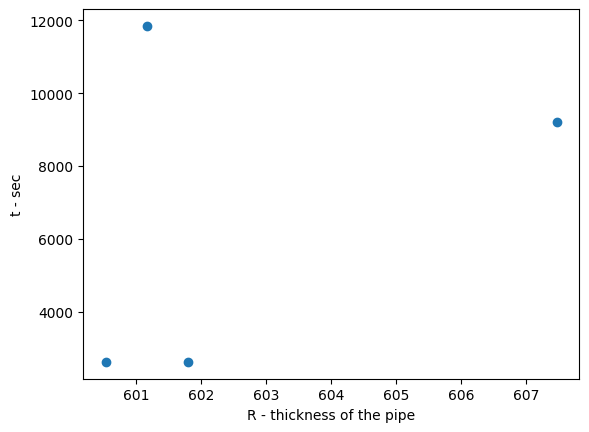

In [ ]:
plt.scatter(R_T_train[:, 0], R_T_train[:, 1])
plt.xlabel("R - thickness of the pipe")
plt.ylabel("t - sec")

Text(0, 0.5, 't - sec')

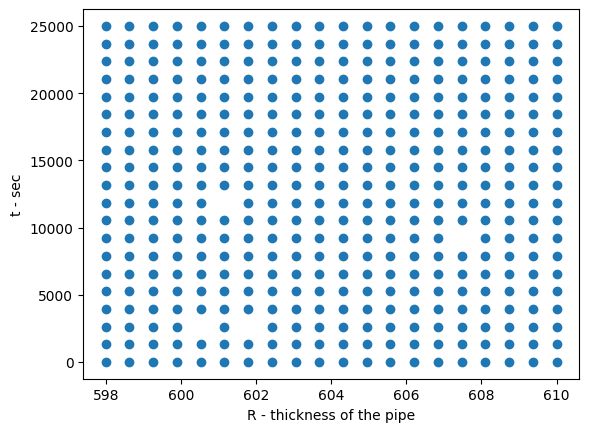

In [ ]:
plt.scatter(R_T_test[:, 0], R_T_test[:, 1])
plt.xlabel("R - thickness of the pipe")
plt.ylabel("t - sec")

In [ ]:
R_train_scaled = min_max_scale(R_T_train[:, 0])[0].reshape(-1, 1)
T_train_scaled = min_max_scale(R_T_train[:, 1])[0].reshape(-1, 1)
R_T_train_scaled = np.concatenate([R_train_scaled, T_train_scaled], axis=1)

R_test_scaled =  min_max_scale(R_T_test[:, 0])[0].reshape(-1, 1)
T_test_scaled = min_max_scale(R_T_test[:, 1])[0].reshape(-1, 1)
R_T_test_scaled = np.concatenate([R_test_scaled, T_test_scaled], axis=1)

R_scaled =  min_max_scale(R_T[:, 0])[0].reshape(-1, 1)
T_scaled = min_max_scale(R_T[:, 1])[0].reshape(-1, 1)
R_T_scaled = np.concatenate([R_scaled, T_scaled], axis=1)

In [ ]:
R_T_train_tn = torch.tensor(R_T_train_scaled, dtype=torch.float32)
R_T_test_tn = torch.tensor(R_T_test_scaled, dtype=torch.float32)

In [ ]:
R_T_tn = torch.tensor(R_T_scaled, dtype=torch.float32)

In [ ]:
R_train_scaled.shape, T_train_scaled.shape, R_T_train_scaled.shape, C_train.shape

((4, 1), (4, 1), (4, 2), (4,))

In [ ]:
R_test_scaled.shape, T_test_scaled.shape, R_T_test_scaled.shape, C_test.shape

((396, 1), (396, 1), (396, 2), (396,))

In [ ]:
R_scaled.shape, T_scaled.shape, R_T_scaled.shape, C_values.shape

((400, 1), (400, 1), (400, 2), (400,))

Text(0, 0.5, 't - sec')

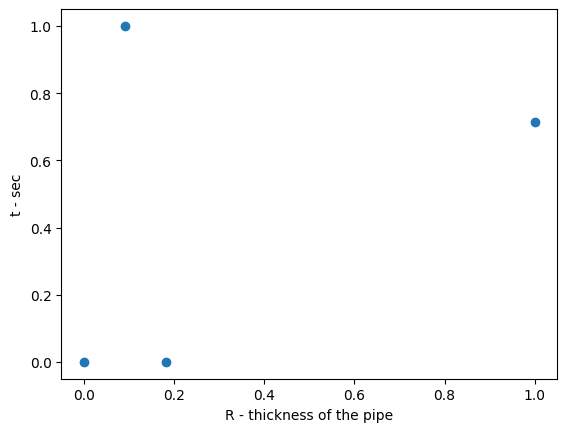

In [ ]:
plt.scatter(R_T_train_scaled[:, 0], R_T_train_scaled[:, 1])
plt.xlabel("R - thickness of the pipe")
plt.ylabel("t - sec")

Text(0, 0.5, 't - sec')

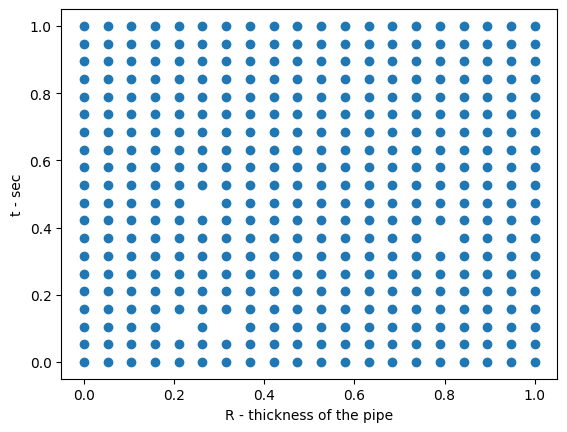

In [ ]:
plt.scatter(R_T_test_scaled[:, 0], R_T_test_scaled[:, 1])
plt.xlabel("R - thickness of the pipe")
plt.ylabel("t - sec")

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# def physics_loss_fn(model, r, t, D):
#     # Ensure r and t have the right shape and require gradients
#     r = r.clone().detach().requires_grad_(True)
#     t = t.clone().detach().requires_grad_(True)

#     # Pass r and t through the model
#     C = model(torch.cat((r, t), dim=1))

#     # Compute partial derivatives
#     dC_dt = torch.autograd.grad(C, t, grad_outputs=torch.ones_like(C), create_graph=True)[0]
#     dC_dr = torch.autograd.grad(C, r, grad_outputs=torch.ones_like(C), create_graph=True)[0]
#     d2C_dr2 = torch.autograd.grad(dC_dr, r, grad_outputs=torch.ones_like(C), create_graph=True)[0]

#     # Compute the differential equation residual
#     lhs = dC_dt
#     epsilon = 1e-6
#     rhs = D * (d2C_dr2 + (1/(r + epsilon)) * dC_dr)
#     residual = lhs - rhs

#     # Physics loss: mean squared residual of the differential equation
#     loss = torch.mean(residual ** 2)
#     return loss

In [ ]:
def physics_loss_fn(model, D, physics_grid):
    # Ensure r and t have the right shape and require gradients
    r = physics_grid[:, 0].clone().detach().requires_grad_(True).reshape(-1, 1)
    t = physics_grid[:, 1].clone().detach().requires_grad_(True).reshape(-1, 1)

    # Pass r and t through the model
    C = model(torch.cat((r, t), dim=1))

    # Compute partial derivatives
    dC_dt = torch.autograd.grad(C, t, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    dC_dr = torch.autograd.grad(C, r, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    d2C_dr2 = torch.autograd.grad(dC_dr, r, grad_outputs=torch.ones_like(C), create_graph=True)[0]

    # Compute the differential equation residual
    lhs = dC_dt
    epsilon = 1e-6
    rhs = D * (d2C_dr2 + (1/(r + epsilon)) * dC_dr)
    residual = lhs - rhs

    # Physics loss: mean squared residual of the differential equation
    physics_loss = torch.mean(residual ** 2)

    return physics_loss


In [ ]:
def calc_boundary_loss(model, r1=0, r2=1, t_start=0, t_finish=1, N=10):
  """
    should be c1 - 4, but C scaled for NN training
    C(r1, t) = 1
    C(r2, t) = 0
    C(r, t_start) = 0
  """
  t = torch.linspace(t_start, t_finish, N).reshape(-1, 1)
  r1_t = torch.cat((torch.full((N, 1), r1), t), dim=1).to(device)
  r2_t = torch.cat((torch.full((N, 1), r2), t), dim=1).to(device)
  r = torch.linspace(r1, r2, N).reshape(-1, 1)
  r_t0 = torch.cat((r, torch.full((N, 1), 0)), dim=1).to(device)
  C_r1_t = model(r1_t)
  C_r2_t = model(r2_t)
  C_r_t0 = model(r_t0)
  loss_value = torch.mean((C_r1_t-1)**2+(C_r2_t-0)**2+(C_r_t0-0)**2)
  return loss_value

In [ ]:
def generate_physics_grid(r_min, r_max, t_min, t_max, num_points=50):
    r_values = torch.linspace(r_min, r_max, num_points)
    t_values = torch.linspace(t_min, t_max, num_points)

    X, Y = torch.meshgrid(r_values, t_values, indexing='ij')  # 'ij' indexing for Cartesian order

    # Reshape and concatenate to form Cartesian product
    cartesian_product = torch.stack([X.flatten(), Y.flatten()], dim=1)
    return cartesian_product.to(device)

In [ ]:
R_T_train_tn.shape, R_T_test_tn.shape

(torch.Size([4, 2]), torch.Size([396, 2]))

In [ ]:
model = ComplexNN().to(device)

In [ ]:
#  assert False

In [ ]:
train_dataset = TensorDataset(R_T_train_tn, torch.tensor(C_train.reshape(-1, 1), dtype=torch.float32))
test_dataset = TensorDataset(R_T_test_tn, torch.tensor(C_test.reshape(-1, 1), dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize the model, optimizer, and loss function
# model = ComplexNN().to(device)
# model = SimpleNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.MSELoss()
criterion = nn.L1Loss()

# Alpha parameter to weight the physics loss
alpha_boundary = 2
alpha_physics = 0.1
# alpha_physics = 0
alpha_data = 1

# Generate points over the entire interval for physics loss
physics_grid = generate_physics_grid(0.1, 0.9, 0.1, 0.9, num_points=300)

# Training loop
num_epochs = 6000
model.train()

for epoch in range(num_epochs):

    running_loss = 0.0
    running_loss_phys = 0
    running_loss_data = 0
    running_loss_boundary = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        # Forward pass and MSE loss computation
        outputs = model(X_batch)

        # Data loss
        mse_loss = criterion(outputs, y_batch)

        # Boundary loss
        boundary_loss = calc_boundary_loss(model, r1=0, r2=1,
                                           t_start=0, t_finish=1, N=10)
        # Physics-based loss
        physics_loss = physics_loss_fn(model, D, physics_grid)

        # Total loss
        loss = alpha_data*mse_loss
        loss += alpha_boundary*boundary_loss
        loss += alpha_physics*physics_loss

        # Backward pass and optimization
        loss.backward()

        # Clip gradients to avoid explosion
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()*X_batch.size(0)
        running_loss_data += alpha_data*mse_loss.item()*X_batch.size(0)
        running_loss_phys += alpha_physics*physics_loss.item()
        running_loss_boundary += alpha_boundary*boundary_loss

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_loss_phys = running_loss_phys
    epoch_loss_data = alpha_data*(running_loss_data / len(train_loader.dataset))
    epoch_loss_boundary_loss = running_loss_boundary
    if (epoch+1) % 500 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')
        print(f'Epoch {epoch+1}/{num_epochs}, Data Loss: {epoch_loss_data:.4f}')
        print(f'Epoch {epoch+1}/{num_epochs}, Boundary Loss: {epoch_loss_boundary_loss:.4f}')
        print(f'Epoch {epoch+1}/{num_epochs}, Physics Loss: {epoch_loss_phys:.4f}')

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


# Evaluate on the test set
model.eval()
with torch.no_grad():
    test_loss = 0.0
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(device))
        loss = criterion(outputs, y_batch.to(device))
        test_loss += loss.item() * X_batch.size(0)

    test_loss = test_loss / len(test_loader.dataset)
    print(f'Test Loss: {test_loss:.4f}')

# inference for whole domain
model.eval()
C_pred = []
for r, t in R_T_scaled:
  inference_point = torch.tensor([[r, t]], dtype=torch.float32)
  with torch.no_grad():
      prediction = model(inference_point.to(device))
      C_pred.append(prediction.item())

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting the surface
ax.scatter(R_T[:, 0], R_T[:, 1], C_pred, color='blue')
ax.scatter(R_T[:, 0], R_T[:, 1], C_values, color='red')

# Setting labels
ax.set_xlabel('R (mm)')
ax.set_ylabel('T (secs)')
ax.set_zlabel('C (ppm)')

plt.title("Hydrogen distribution")

# Displaying the plot
plt.show()

In [ ]:
#  assert False

In [ ]:
# torch.save(model.state_dict(), "10%_training_0.16test_loss_cool_results.png")

In [ ]:
# train_dataset = TensorDataset(R_T_train_tn, torch.tensor(C_train.reshape(-1, 1), dtype=torch.float32))
# test_dataset = TensorDataset(R_T_test_tn, torch.tensor(C_test.reshape(-1, 1), dtype=torch.float32))

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# # Initialize the model, optimizer, and loss function
# model = ComplexNN().to(device)
# # model = SimpleNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
# # criterion = nn.MSELoss()
# criterion = nn.L1Loss()

In [ ]:
# Doesn't work so far

# Alpha parameter to weight the physics loss
# alpha = 0.01  # Adjust this parameter based on the importance of the physics loss

# Define the interval for the physics loss calculation
r_min, r_max = R_T_train_scaled[:, 0].min(), R_T_train_scaled[:, 0].max()
t_min, t_max = R_T_train_scaled[:, 1].min(), R_T_train_scaled[:, 1].max()

# Generate points over the entire interval for physics loss
# r_grid, t_grid = generate_physics_grid(r_min, r_max, t_min, t_max, num_points=10)
# r_grid = r_grid.to(device)
# t_grid = t_grid.to(device)

# Training loop
num_epochs = 100
model.train()

for epoch in range(num_epochs):

    running_loss = 0.0
    # running_loss_phys = 0
    # running_loss_data = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        # Forward pass and MSE loss computation
        outputs = model(X_batch)
        mse_loss = criterion(outputs, y_batch)

        # Backward pass and optimization
        mse_loss.backward()
        running_loss += mse_loss.item() * X_batch.size(0)

        optimizer.step()

    for n in range(10):
      optimizer.zero_grad()
      physics_loss = physics_loss_fn(model, r_grid, t_grid, D)
      physics_loss.backward()
      optimizer.step()

    epoch_loss = running_loss / len(train_loader.dataset)

    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Data Loss: {epoch_loss:.4f}')
        # print(f'Epoch {epoch+1}/{num_epochs}, Physics Loss: {physics_loss:.4f}')


In [ ]:
# Evaluate on the test set
model.eval()
with torch.no_grad():
    test_loss = 0.0
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch.to(device))
        loss = criterion(outputs, y_batch.to(device))
        test_loss += loss.item() * X_batch.size(0)

    test_loss = test_loss / len(test_loader.dataset)
    print(f'Test Loss: {test_loss:.4f}')

In [ ]:
# Example prediction
model.eval()
C_pred = []
for r, t in R_T_scaled:
  inference_point = torch.tensor([[r, t]], dtype=torch.float32)  # Example input (R=r, t=t)
  with torch.no_grad():
      prediction = model(inference_point.to(device))
      C_pred.append(prediction.item())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
 R_T_train, C_train, R_T_test, C_test, R_T, C_values

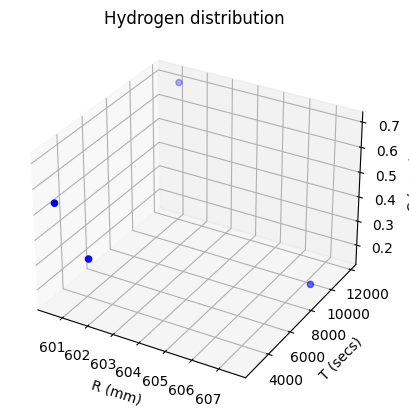

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting the surface
ax.scatter(R_T_train[:, 0], R_T_train[:, 1], C_train, color='blue')
# ax.scatter(R_T[:, 0], R_T[:, 1], C_values, color='red')

# Setting labels
ax.set_xlabel('R (mm)')
ax.set_ylabel('T (secs)')
ax.set_zlabel('C (ppm)')

plt.title("Hydrogen distribution")

# Displaying the plot
plt.show()

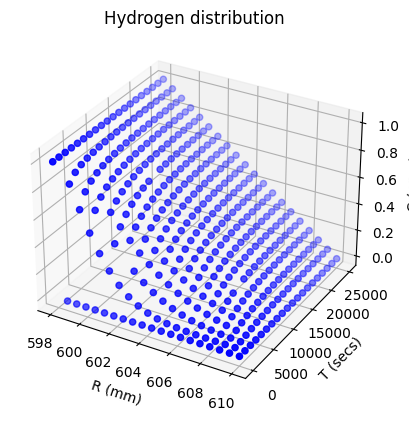

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting the surface
ax.scatter(R_T_test[:, 0], R_T_test[:, 1], C_test, color='blue')
# ax.scatter(R_T[:, 0], R_T[:, 1], C_values, color='red')

# Setting labels
ax.set_xlabel('R (mm)')
ax.set_ylabel('T (secs)')
ax.set_zlabel('C (ppm)')

plt.title("Hydrogen distribution")

# Displaying the plot
plt.show()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting the surface
ax.scatter(R_T[:, 0], R_T[:, 1], C_pred, color='blue')
ax.scatter(R_T[:, 0], R_T[:, 1], C_values, color='red')

# Setting labels
ax.set_xlabel('R (mm)')
ax.set_ylabel('T (secs)')
ax.set_zlabel('C (ppm)')

plt.title("Hydrogen distribution")

# Displaying the plot
plt.show()

In [ ]:
max(C_pred), max(C_values)

In [ ]:
t_finish

In [ ]:
# !pip install torch-summary
# !pip install torchviz

In [ ]:
# from torchsummary import summary
# summary(model, (2,))

In [ ]:
# !pip install loss-landscapes

In [ ]:
# metric = Loss(loss_function, X, y)
# landscape = random_plane(model, metric, normalize='filter')

In [ ]:
# # Evaluate on the test set
# model.eval()
# with torch.no_grad():
#     for X_batch, y_batch in test_loader:
#         outputs = model(X_batch.to(device))
#         # metric = loss_landscapes.Loss(criterion, X_batch.to(device),  y_batch.to(device))
#         landscape = loss_landscapes.random_plane(model, criterion)
#         print(landspace)
#         break

## Test gradients

In [ ]:
def physics_loss_fn(model, D, physics_grid):
    # Ensure r and t have the right shape and require gradients
    r = physics_grid[:, 0].clone().detach().requires_grad_(True).reshape(-1, 1)
    t = physics_grid[:, 1].clone().detach().requires_grad_(True).reshape(-1, 1)

    # Pass r and t through the model
    C = model(torch.cat((r, t), dim=1))

    # Compute partial derivatives
    dC_dt = torch.autograd.grad(C, t, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    dC_dr = torch.autograd.grad(C, r, grad_outputs=torch.ones_like(C), create_graph=True)[0]
    d2C_dr2 = torch.autograd.grad(dC_dr, r, grad_outputs=torch.ones_like(C), create_graph=True)[0]

    # Compute the differential equation residual
    lhs = dC_dt
    epsilon = 1e-6
    rhs = D * (d2C_dr2 + (1/(r + epsilon)) * dC_dr)
    residual = lhs - rhs

    # Physics loss: mean squared residual of the differential equation
    physics_loss = torch.mean(residual ** 2)

    return physics_loss


In [ ]:
epsilon = 1e-4
# df/dr
r, t = 0, 0
(model(torch.tensor([[r, t]]))-model(torch.tensor([r, t+epsilon])))/epsilon
# df/dt


### Visualize train and test points

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plotting the surface
# ax.scatter(R_T[:, 0], R_T[:, 1], C_pred, color='blue')
ax.scatter(R_T[:, 0], R_T[:, 1], C_values, color='red')

# Setting labels
ax.set_xlabel('R (mm)')
ax.set_ylabel('T (secs)')
ax.set_zlabel('C (ppm)')

plt.title("Hydrogen distribution")

# Displaying the plot
plt.show()

In [ ]:
!pip3 install graphviz

In [ ]:
!python3 -m graphviz -Tpng -O architecture.txt

In [ ]:
!sudo apt-get install graphviz

In [ ]:
!dot -Tpng -O architecture.txt

### Text for visualization

